## Tips

- **Start simple** — a single GRU with 64 units is a good first attempt.
  Only add complexity (stacking, dropout, bidirectional) if the simple model
  is clearly underfitting or overfitting.

- **Use many epochs** — RNNs on time series converge slowly. 10 or 20 epochs
  is almost never enough. Use **at least 100 epochs** and let early stopping
  decide when to stop. The best checkpoint is saved automatically by
  `ModelCheckpoint` — you will not miss the optimal point even if you
  train for too long.

- **Watch the train/val gap** — if train MAE is much lower than val MAE
  you are overfitting. Add dropout, reduce `hidden_size`, or increase
  early stopping patience to give regularization more time to work.

- **Use TensorBoard** — run `tensorboard --logdir runs` in your terminal
  to monitor train and val curves in real time. A healthy training curve
  shows both losses decreasing together. A diverging val curve means overfitting.

- **Learning rate matters** — if the loss is not decreasing after the first
  few epochs, try a lower learning rate (`1e-4` instead of `1e-3`).
  Use `ReduceLROnPlateau` to automatically decay the learning rate when
  val MAE stops improving.

- **The sklearn baseline is hard to beat** — `HistGradientBoosting` with
  explicit lag features is a very strong baseline for tabular time series.
  This is not a failure of the RNN — it reflects a fundamental difference
  between the two approaches: tree models get temporal information from
  hand-crafted features, while RNNs must learn it from raw sequences.
  Getting within 10 bikes/hour of the sklearn baseline (< 44 bikes/hour)
  is an excellent result.

## Libraries

In [ ]:
import os
import copy
import torch
import joblib
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

## Import data

In [11]:
save_dir = "data/bike_processed"

# --- Load arrays ---
raw_data = np.load(os.path.join(save_dir, "raw_data.npy"))
counts = np.load(os.path.join(save_dir, "counts.npy"))

# count_stats = np.load(os.path.join(save_dir, "count_stats.npy"))
train_idx = np.load(os.path.join(save_dir, "train_idx.npy"))
val_idx = np.load(os.path.join(save_dir, "val_idx.npy"))
test_idx = np.load(os.path.join(save_dir, "test_idx.npy"))
naive_mae = np.load(os.path.join(save_dir, "naive_mae.npy"))
gbrt_mae = np.load(os.path.join(save_dir, "gbrt_mae.npy"))
preprocessor = joblib.load(os.path.join(save_dir, "preprocessor_rnn.pkl"))

# --- Recover split sizes ---
num_train = len(train_idx)
num_val = len(val_idx)
num_test = len(test_idx)

# --- Count stats in the training set ---
count_mean = np.mean(counts[train_idx])
count_std = np.std(counts[train_idx])

# --- Sanity check ---
print(f"raw_data shape: {raw_data.shape}")
print(f"counts shape: {counts.shape}")
print(f"train/val/test: {num_train} / {num_val} / {num_test}")
print(f"counts range: {counts.min():.0f} to {counts.max():.0f} bikes/hour")
print(f"counts mean train: {count_mean:.2f} bikes/hour | counts std train: {count_std:.2f} bikes/hour")
print(f"\nNaive baseline — Val MAE: {naive_mae[0]:.2f} | Test MAE: {naive_mae[1]:.2f} bikes/hour")
print(f"GBRT baseline — Val MAE: {gbrt_mae[0]:.2f} | Test MAE: {gbrt_mae[1]:.2f} bikes/hour")

raw_data shape: (17210, 28)
counts shape: (17210,)
train/val/test: 12047 / 2581 / 2582
counts range: 1 to 977 bikes/hour
counts mean train: 161.75 bikes/hour | counts std train: 153.40 bikes/hour

Naive baseline — Val MAE: 93.26 | Test MAE: 80.78 bikes/hour
GBRT baseline — Val MAE: 35.02 | Test MAE: 33.94 bikes/hour


In [12]:
count_norm = (counts - count_mean) / count_std
count_norm

array([-0.95666707, -0.9240718 , -0.6567903 , ..., -0.4677376 ,
       -0.6567903 , -0.735019  ], dtype=float32)

## Build datasets and dataloaders

In [13]:
class TimeseriesDataset(Dataset):
    def __init__(self, data, targets, sequence_length, sampling_rate, delay, start_index, end_index):
        self.data = data
        self.targets = targets
        self.sequence_length = sequence_length
        self.sampling_rate = sampling_rate
        self.delay = delay

        self.indices = np.arange(start_index, end_index)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start = self.indices[idx]
        steps = np.arange(start, start + self.sequence_length * self.sampling_rate,
                          self.sampling_rate)
        x = self.data[steps]
        y = self.targets[start + self.delay]
        return torch.tensor(x, dtype = torch.float32), torch.tensor(y, dtype = torch.float32)

In [14]:
sampling_rate = 1     # already hourly
sequence_length = 24  # look back 24 hours
delay = 1             # predict 1 hour ahead
batch_size = 256

train_dataset = TimeseriesDataset(
    data = raw_data, targets = count_norm,
    sequence_length = sequence_length, sampling_rate = sampling_rate,
    delay = delay, start_index = 0, end_index = num_train
)
val_dataset = TimeseriesDataset(
    data = raw_data, targets = count_norm,
    sequence_length = sequence_length, sampling_rate = sampling_rate,
    delay = delay, start_index = num_train, end_index = num_train + num_val
)
test_dataset = TimeseriesDataset(
    data = raw_data, targets = count_norm,
    sequence_length = sequence_length, sampling_rate = sampling_rate,
    delay = delay, start_index = num_train + num_val,
    end_index = len(raw_data) - sequence_length * sampling_rate - delay
)

train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = False)
val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)

# --- Sanity check ---
inputs, targets = next(iter(train_loader))
print(f"Input shape:  {inputs.shape}")   # (batch_size, sequence_length, input_size)
print(f"Target shape: {targets.shape}")  # (batch_size,)
print(f"Target range: {targets.min():.0f} to {targets.max():.0f}")

Input shape:  torch.Size([256, 24, 28])
Target shape: torch.Size([256])
Target range: -1 to 0


## Setup

In [15]:
input_size = inputs.shape[-1]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Input size: {input_size} | Device: {device}")

Input size: 28 | Device: cpu


## Generic model definition

In [16]:
class RecurrentModel(nn.Module):
    def __init__(self, input_size, hidden_size = 64, num_layers = 1, dropout = 0.0, cell_type = 'gru'):
        super().__init__()
        self.cell_type = cell_type
        rnn_cls = {'rnn': nn.RNN, 'lstm': nn.LSTM, 'gru': nn.GRU}[cell_type]
        self.rnn = rnn_cls(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True,
            dropout = dropout if num_layers > 1 else 0.0,
        )
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, hidden = self.rnn(x)
        h_n = hidden[0] if self.cell_type == 'lstm' else hidden
        return self.fc(self.drop(h_n[-1])).squeeze(1)

## Training infrastructure

In [17]:
def evaluate_metrics(model, loader):
    model.eval()
    abs_err = 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            diff = pred - y
            abs_err += diff.abs().sum().item()
    n = len(loader.dataset)
    return abs_err / n


def train_model(model, train_loader, val_loader, lr = 1e-3, num_epochs = 150, patience = 15, name = None, verbose = True):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr = lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience = 7, factor = 0.5)
    crit = nn.MSELoss()

    checkpoint_dir = "checkpoints"
    os.makedirs(checkpoint_dir, exist_ok = True)

    best_val, best_weights, no_improve = float('inf'), None, 0
    history = {'train': [], 'val': []}

    for epoch in range(1, num_epochs + 1):
        model.train()
        total_mae = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            pred = model(x)
            crit(pred, y).backward()
            # Clip gradients to prevent exploding gradients, especially in vanilla RNN
            nn.utils.clip_grad_norm_(model.parameters(), max_norm = 1.0)
            opt.step()
            # MAE tracked from pre-step forward pass — standard epoch-level approximation
            total_mae += (pred.detach() - y).abs().sum().item()

        train_mae = total_mae / len(train_loader.dataset)
        val_mae = evaluate_metrics(model, val_loader)
        sched.step(val_mae)

        history['train'].append(train_mae)
        history['val'].append(val_mae)

        if val_mae < best_val:
            best_val = val_mae
            best_weights = copy.deepcopy(model.state_dict())
            no_improve = 0
            if name is not None:
                torch.save(best_weights, os.path.join(checkpoint_dir, f"{name}.pt"))
        else:
            no_improve += 1

        if verbose and epoch % 20 == 0:
            print(f"  Epoch {epoch:03d} | train MAE: {train_mae:.4f} | val MAE: {val_mae:.4f}")

        if no_improve >= patience:
            if verbose:
                print(f"  Early stopping at epoch {epoch} (best val MAE: {best_val:.4f})")
            break

    model.load_state_dict(best_weights)
    return model, history, best_val

## Experiment 1: Architecture Comparison (RNN vs LSTM vs GRU)
Firstly, three architectures will be tested: RNN, LSTM and GRU. All of them will be tested with the same hyperparameters in order to isolate the effect of the recurrent cell type. These are:
- **Sequence length:** `seq_len=24`
- **Number of hidden layers:** `hidden=64`
- **Learning rate:** `lr=1e-3`

**Hypothesis:** LSTM and GRU should outperform Vanilla RNN because their gating mechanisms better handle the vanishing-gradient problem over 24-step sequences.

In [18]:
exp1_results = {}
hidden_size = 64

for arch in ['rnn', 'lstm', 'gru']:
    print(f"\n{'='*50}")
    print(f"  {arch.upper()}  |  seq_len={sequence_length}  |  hidden={hidden_size}")
    print('='*50)
    m = RecurrentModel(input_size = input_size, hidden_size = hidden_size, num_layers = 1, dropout = 0.0, cell_type = arch)
    m, hist, best_val = train_model(m, train_loader, val_loader, lr = 1e-3, num_epochs = 150, patience = 15, name = f"exp1_{arch}")
    exp1_results[arch] = {
        'model': m,
        'history': hist,
        'val_mae': best_val * count_std,
    }


  RNN  |  seq_len=24  |  hidden=64
  Epoch 020 | train MAE: 0.2784 | val MAE: 0.5009
  Epoch 040 | train MAE: 0.2414 | val MAE: 0.4151
  Epoch 060 | train MAE: 0.1695 | val MAE: 0.3850
  Epoch 080 | train MAE: 0.1744 | val MAE: 0.3006
  Early stopping at epoch 97 (best val MAE: 0.2893)

  LSTM  |  seq_len=24  |  hidden=64
  Epoch 020 | train MAE: 0.2605 | val MAE: 0.4797
  Epoch 040 | train MAE: 0.2838 | val MAE: 0.4147
  Epoch 060 | train MAE: 0.1650 | val MAE: 0.2815
  Epoch 080 | train MAE: 0.1346 | val MAE: 0.2524
  Epoch 100 | train MAE: 0.1237 | val MAE: 0.2470
  Epoch 120 | train MAE: 0.1177 | val MAE: 0.2478
  Early stopping at epoch 120 (best val MAE: 0.2441)

  GRU  |  seq_len=24  |  hidden=64
  Epoch 020 | train MAE: 0.3199 | val MAE: 0.5041
  Epoch 040 | train MAE: 0.1989 | val MAE: 0.2919
  Epoch 060 | train MAE: 0.2139 | val MAE: 0.2579
  Epoch 080 | train MAE: 0.1344 | val MAE: 0.2410
  Epoch 100 | train MAE: 0.1276 | val MAE: 0.2346
  Epoch 120 | train MAE: 0.1242 | va

In [19]:
print("\n=== Experiment 1 Results  (seq_len=24, hidden=64) ===")
print(f"{'Architecture':<20} {'Val MAE':>10}")
print("-" * 34)
for arch, r in exp1_results.items():
    print(f"{arch.upper():<20} {r['val_mae']:>9.2f}")
print("-" * 34)
print(f"{'Naive baseline':<20} {naive_mae[0]:>9.2f}")
print(f"{'HistGradientBoosting':<20} {gbrt_mae[0]:>9.2f}")


=== Experiment 1 Results  (seq_len=24, hidden=64) ===
Architecture            Val MAE
----------------------------------
RNN                      44.38
LSTM                     37.44
GRU                      35.21
----------------------------------
Naive baseline           93.26
HistGradientBoosting     35.02


After the first experiment, we can conclude that GRU outperformed both LSTM and vanilla RNN, confirming the hypothesis. The gating mechanisms of GRU and LSTM give them a clear advantage over plain RNN on 24-step sequences, and GRU achieves this with fewer parameters than LSTM — making it both more accurate and more efficient for this task.

## Experiment 2: Sequence length effect
Secondly, the look-back window is varied on the GRU model to see its effect. The values that were tested out were:

| `seq_len` | Look-back period | Notes |
|---|---|---|
| 12 | 12 hours | Half a day — may miss daily rhythm |
| 24 | 24 hours | Full day — matches the daily cycle |
| 48 | 48 hours | Two days — can capture day-over-day patterns |

**Hypothesis:** `seq_len=24` should perform best since it captures one full diurnal cycle, which is the dominant periodic pattern in bike demand.

In [20]:
exp2_results = {}
hidden_size = 64

for seq_len in [12, 24, 48]:
    print(f"\n{'='*50}")
    print(f"  GRU  |  seq_len={seq_len}  |  hidden={hidden_size}")
    print('='*50)

    kw = dict(data = raw_data, targets = count_norm, sequence_length = seq_len,
              sampling_rate = sampling_rate, delay = delay)
    tr_l = DataLoader(TimeseriesDataset(**kw, start_index = 0, end_index = num_train),
                      batch_size = 256, shuffle = False)
    vl_l = DataLoader(TimeseriesDataset(**kw, start_index = num_train, end_index = num_train + num_val),
                      batch_size = 256, shuffle = False)

    m = RecurrentModel(input_size = input_size, hidden_size = hidden_size, num_layers = 1, dropout = 0.0, cell_type = 'gru')
    m, hist, best_val = train_model(m, tr_l, vl_l, lr = 1e-3, num_epochs = 150, patience = 15, name = f"exp2_seq{seq_len}")
    exp2_results[seq_len] = {
        'model': m,
        'history': hist,
        'val_mae': best_val * count_std,
    }


  GRU  |  seq_len=12  |  hidden=64
  Epoch 020 | train MAE: 0.2296 | val MAE: 0.4012
  Epoch 040 | train MAE: 0.1983 | val MAE: 0.3564
  Epoch 060 | train MAE: 0.1483 | val MAE: 0.2865
  Epoch 080 | train MAE: 0.1216 | val MAE: 0.2361
  Epoch 100 | train MAE: 0.1150 | val MAE: 0.2335
  Early stopping at epoch 102 (best val MAE: 0.2319)

  GRU  |  seq_len=24  |  hidden=64
  Epoch 020 | train MAE: 0.4183 | val MAE: 0.6449
  Epoch 040 | train MAE: 0.1947 | val MAE: 0.3440
  Epoch 060 | train MAE: 0.1439 | val MAE: 0.2708
  Epoch 080 | train MAE: 0.1338 | val MAE: 0.2494
  Epoch 100 | train MAE: 0.1276 | val MAE: 0.2418
  Epoch 120 | train MAE: 0.1224 | val MAE: 0.2400
  Epoch 140 | train MAE: 0.1196 | val MAE: 0.2424
  Early stopping at epoch 141 (best val MAE: 0.2369)

  GRU  |  seq_len=48  |  hidden=64
  Epoch 020 | train MAE: 0.3823 | val MAE: 0.5665
  Epoch 040 | train MAE: 0.2955 | val MAE: 0.4467
  Epoch 060 | train MAE: 0.1864 | val MAE: 0.3246
  Epoch 080 | train MAE: 0.1595 | va

In [21]:
print("\n=== Experiment 2 Results  (GRU, hidden=64) ===")
print(f"{'seq_len':<20} {'Val MAE':>10}")
print("-" * 33)
for seq_len, r in exp2_results.items():
    print(f"{seq_len:<20} {r['val_mae']:>9.2f}")
print("-" * 33)
print(f"{'Naive':<20} {naive_mae[0]:>9.2f}")
print(f"{'HistGradientBoosting':<20} {gbrt_mae[0]:>9.2f}")


=== Experiment 2 Results  (GRU, hidden=64) ===
seq_len                 Val MAE
---------------------------------
12                       35.57
24                       36.33
48                       45.70
---------------------------------
Naive                    93.26
HistGradientBoosting     35.02


Contrary to the hypothesis, `seq_len=12` (half a day) yielded the best validation MAE, narrowly beating `seq_len=24`. The 48-step window performed worst, likely because longer sequences make gradient flow harder in a single-layer GRU, outweighing the benefit of extra context. A 12-hour window is sufficient to capture the dominant demand patterns.

## Experiment 3: Depth Ablation (Stacked GRU Layers)
Now, we're going to test the effect of stacking recurrent layers to see if they allow the network to learn hierarchical temporal representations. These deeper models are usually harder to train and more prone to overfitting, so a 0.2 dropout is applied between layers when `num_layers > 1` to regularise the stacked model.

| `num_layers` | Dropout | Notes |
|---|---|---|
| 1 | 0.0 | Single-layer baseline |
| 2 | 0.2 | One intermediate dropout |
| 3 | 0.2 | Two intermediate dropouts |

**Hypothesis:** Stacking 2 GRU layers should improve over a single layer by capturing higher-order temporal patterns. A 3-layer model may overfit on this dataset (~12K training samples), since the added regularisation from dropout may not fully compensate for the increased capacity.

In [22]:
exp3_results = {}
hidden_size = 64

for num_layers in [1, 2, 3]:
    dropout = 0.2 if num_layers > 1 else 0.0
    print(f"\n{'='*50}")
    print(f"  GRU  |  num_layers={num_layers}  |  dropout={dropout}  |  hidden={hidden_size}")
    print('='*50)
    m = RecurrentModel(input_size = input_size, hidden_size = hidden_size, num_layers = num_layers, dropout = dropout, cell_type = 'gru')
    m, hist, best_val = train_model(m, train_loader, val_loader, lr = 1e-3, num_epochs = 150, patience = 15, name = f"exp3_layers{num_layers}")
    exp3_results[num_layers] = {
        'model': m,
        'history': hist,
        'val_mae': best_val * count_std,
    }


  GRU  |  num_layers=1  |  dropout=0.0  |  hidden=64
  Epoch 020 | train MAE: 0.3670 | val MAE: 0.5628
  Epoch 040 | train MAE: 0.1896 | val MAE: 0.3366
  Epoch 060 | train MAE: 0.1461 | val MAE: 0.2662
  Epoch 080 | train MAE: 0.1345 | val MAE: 0.2397
  Epoch 100 | train MAE: 0.1294 | val MAE: 0.2312
  Epoch 120 | train MAE: 0.1230 | val MAE: 0.2346
  Early stopping at epoch 125 (best val MAE: 0.2300)

  GRU  |  num_layers=2  |  dropout=0.2  |  hidden=64
  Epoch 020 | train MAE: 0.3190 | val MAE: 0.5104
  Epoch 040 | train MAE: 0.2629 | val MAE: 0.3805
  Epoch 060 | train MAE: 0.1980 | val MAE: 0.3120
  Epoch 080 | train MAE: 0.1685 | val MAE: 0.2606
  Epoch 100 | train MAE: 0.1584 | val MAE: 0.2545
  Early stopping at epoch 102 (best val MAE: 0.2483)

  GRU  |  num_layers=3  |  dropout=0.2  |  hidden=64
  Epoch 020 | train MAE: 0.2827 | val MAE: 0.5755
  Epoch 040 | train MAE: 0.2392 | val MAE: 0.4168
  Epoch 060 | train MAE: 0.1987 | val MAE: 0.2819
  Epoch 080 | train MAE: 0.1641 

In [23]:
print("\n=== Experiment 3 Results  (GRU, seq_len=24, hidden=64) ===")
print(f"{'num_layers':<20} {'Val MAE':>10}")
print("-" * 34)
for nl, r in exp3_results.items():
    print(f"{nl:<20} {r['val_mae']:>9.2f}")
print("-" * 34)
print(f"{'Naive':<20} {naive_mae[0]:>9.2f}")
print(f"{'HistGradientBoosting':<20} {gbrt_mae[0]:>9.2f}")


=== Experiment 3 Results  (GRU, seq_len=24, hidden=64) ===
num_layers              Val MAE
----------------------------------
1                        35.29
2                        38.08
3                        34.77
----------------------------------
Naive                    93.26
HistGradientBoosting     35.02


In conclusion, the 3-layer GRU achieved the best validation MAE, though the improvement over the single-layer baseline is modest. The 2-layer model performed notably worse, likely due to training instability. Stacking layers with inter-layer dropout does help, but gains are small relative to the added complexity on this dataset size.

## Experiment 4: Hidden Size Ablation

Using the best `num_layers` found in Experiment 3, three hidden sizes are tested with dropout applied whenever `num_layers > 1`:

| `hidden_size` | Parameters (approx.) | Notes |
|---|---|---|
| 32 | ~5K | Low capacity — likely to underfit |
| 64 | ~20K | Baseline used in Experiments 1–3 |
| 128 | ~75K | Higher capacity — risk of overfitting |

**Hypothesis:** Increasing the hidden size should improve performance up to a point, after which overfitting will dominate. Given the training samples, 128 units is expected to offer the best capacity-regularisation trade-off, while 32 units is likely to underfit.

In [24]:
best_num_layers = min(exp3_results, key = lambda k: exp3_results[k]['val_mae'])
dropout = 0.2 if best_num_layers > 1 else 0.0

exp4_results = {}

for hidden_size in [32, 64, 128]:
    print(f"\n{'='*50}")
    print(f"  GRU  |  hidden={hidden_size}  |  num_layers={best_num_layers}  |  dropout={dropout}")
    print('='*50)
    m = RecurrentModel(input_size = input_size, hidden_size = hidden_size, num_layers = best_num_layers, dropout = dropout, cell_type = 'gru')
    m, hist, best_val = train_model(m, train_loader, val_loader, lr = 1e-3, num_epochs = 150, patience = 15, name = f"exp4_hidden{hidden_size}")
    exp4_results[hidden_size] = {
        'model': m,
        'history': hist,
        'val_mae': best_val * count_std,
    }


  GRU  |  hidden=32  |  num_layers=3  |  dropout=0.2
  Epoch 020 | train MAE: 0.3119 | val MAE: 0.6099
  Epoch 040 | train MAE: 0.2496 | val MAE: 0.3606
  Epoch 060 | train MAE: 0.2236 | val MAE: 0.3219
  Epoch 080 | train MAE: 0.1893 | val MAE: 0.2676
  Epoch 100 | train MAE: 0.1822 | val MAE: 0.2760
  Early stopping at epoch 100 (best val MAE: 0.2595)

  GRU  |  hidden=64  |  num_layers=3  |  dropout=0.2
  Epoch 020 | train MAE: 0.2779 | val MAE: 0.4287
  Epoch 040 | train MAE: 0.2578 | val MAE: 0.3820
  Epoch 060 | train MAE: 0.1791 | val MAE: 0.2510
  Epoch 080 | train MAE: 0.1701 | val MAE: 0.2297
  Early stopping at epoch 91 (best val MAE: 0.2283)

  GRU  |  hidden=128  |  num_layers=3  |  dropout=0.2
  Epoch 020 | train MAE: 0.2971 | val MAE: 0.3657
  Epoch 040 | train MAE: 0.2648 | val MAE: 0.3783
  Epoch 060 | train MAE: 0.1828 | val MAE: 0.2914
  Epoch 080 | train MAE: 0.1969 | val MAE: 0.2535
  Early stopping at epoch 85 (best val MAE: 0.2317)


In [25]:
print(f"\n=== Experiment 4 Results  (GRU, seq_len=24, num_layers={best_num_layers}) ===")
print(f"{'hidden_size':<20} {'Val MAE':>10}")
print("-" * 34)
for hs, r in exp4_results.items():
    print(f"{hs:<20} {r['val_mae']:>9.2f}")
print("-" * 34)
print(f"{'Naive':<20} {naive_mae[0]:>9.2f}")
print(f"{'HistGradientBoosting':<20} {gbrt_mae[0]:>9.2f}")


=== Experiment 4 Results  (GRU, seq_len=24, num_layers=3) ===
hidden_size             Val MAE
----------------------------------
32                       39.81
64                       35.01
128                      35.54
----------------------------------
Naive                    93.26
HistGradientBoosting     35.02


After conducting the experiment, `hidden=64` was the best hidden size for a 3-layer GRU, outperforming both smaller (32) and larger (128) sizes. The larger model offered no benefit, suggesting that with 3 layers, the existing capacity is sufficient and harder to regularise with dropout=0.2 alone within the training budget.

## Final Best Model

Finally, the best hyperparameters identified across all four experiments are combined into a single final model in order to test it with the test set.

The best configuration per experiment is selected automatically from the validation MAE:
- **Architecture** (Exp 1): GRU
- **Sequence length** (Exp 2): `argmin` over `{12, 24, 48}`
- **Num layers** (Exp 3): `argmin` over `{1, 2, 3}`
- **Hidden size** (Exp 4): `argmin` over `{32, 64, 128}`

In [26]:
best_seq_len = min(exp2_results, key = lambda k: exp2_results[k]['val_mae'])
best_hidden_size = min(exp4_results, key = lambda k: exp4_results[k]['val_mae'])
dropout = 0.2 if best_num_layers > 1 else 0.0

print(f"Best config — arch: GRU | seq_len: {best_seq_len} | num_layers: {best_num_layers} | hidden: {best_hidden_size} | dropout: {dropout}")

kw = dict(data = raw_data, targets = count_norm, sequence_length = best_seq_len,
          sampling_rate = sampling_rate, delay = delay)
tr_best = DataLoader(TimeseriesDataset(**kw, start_index = 0, end_index = num_train),
                     batch_size = 256, shuffle = False)
vl_best = DataLoader(TimeseriesDataset(**kw, start_index = num_train, end_index = num_train + num_val),
                     batch_size = 256, shuffle = False)
te_best = DataLoader(TimeseriesDataset(**kw, start_index = num_train + num_val,
                     end_index = len(raw_data) - best_seq_len * sampling_rate - delay),
                     batch_size = 256, shuffle = False)

m_best = RecurrentModel(input_size = input_size, hidden_size = best_hidden_size,
                        num_layers = best_num_layers, dropout = dropout, cell_type = 'gru')
m_best, hist_best, best_val_final = train_model(m_best, tr_best, vl_best,
                                                lr = 1e-3, num_epochs = 200, patience = 20,
                                                name = "best_model")

val_mae_final = best_val_final * count_std
test_mae_final = evaluate_metrics(m_best, te_best) * count_std

print(f"\nFinal Best Model — Val MAE: {val_mae_final:.2f} | Test MAE: {test_mae_final:.2f} bikes/hour")
print(f"GBRT Baseline    — Val MAE: {gbrt_mae[0]:.2f} | Test MAE: {gbrt_mae[1]:.2f} bikes/hour")

Best config — arch: GRU | seq_len: 12 | num_layers: 3 | hidden: 64 | dropout: 0.2
  Epoch 020 | train MAE: 0.3030 | val MAE: 0.5098
  Epoch 040 | train MAE: 0.2790 | val MAE: 0.4049
  Epoch 060 | train MAE: 0.1740 | val MAE: 0.2650
  Epoch 080 | train MAE: 0.1673 | val MAE: 0.2582
  Epoch 100 | train MAE: 0.1475 | val MAE: 0.2403
  Epoch 120 | train MAE: 0.1429 | val MAE: 0.2348
  Early stopping at epoch 123 (best val MAE: 0.2333)

Final Best Model — Val MAE: 35.79 | Test MAE: 35.58 bikes/hour
GBRT Baseline    — Val MAE: 35.02 | Test MAE: 33.94 bikes/hour


## Summary & Visualisation

In this section, training and validation curves for all four experiments are shown in bikes/hour to diagnose overfitting, as a large gap between them signals the model is memorising the training set. Horizontal dotted lines mark the naive and GBRT baselines.

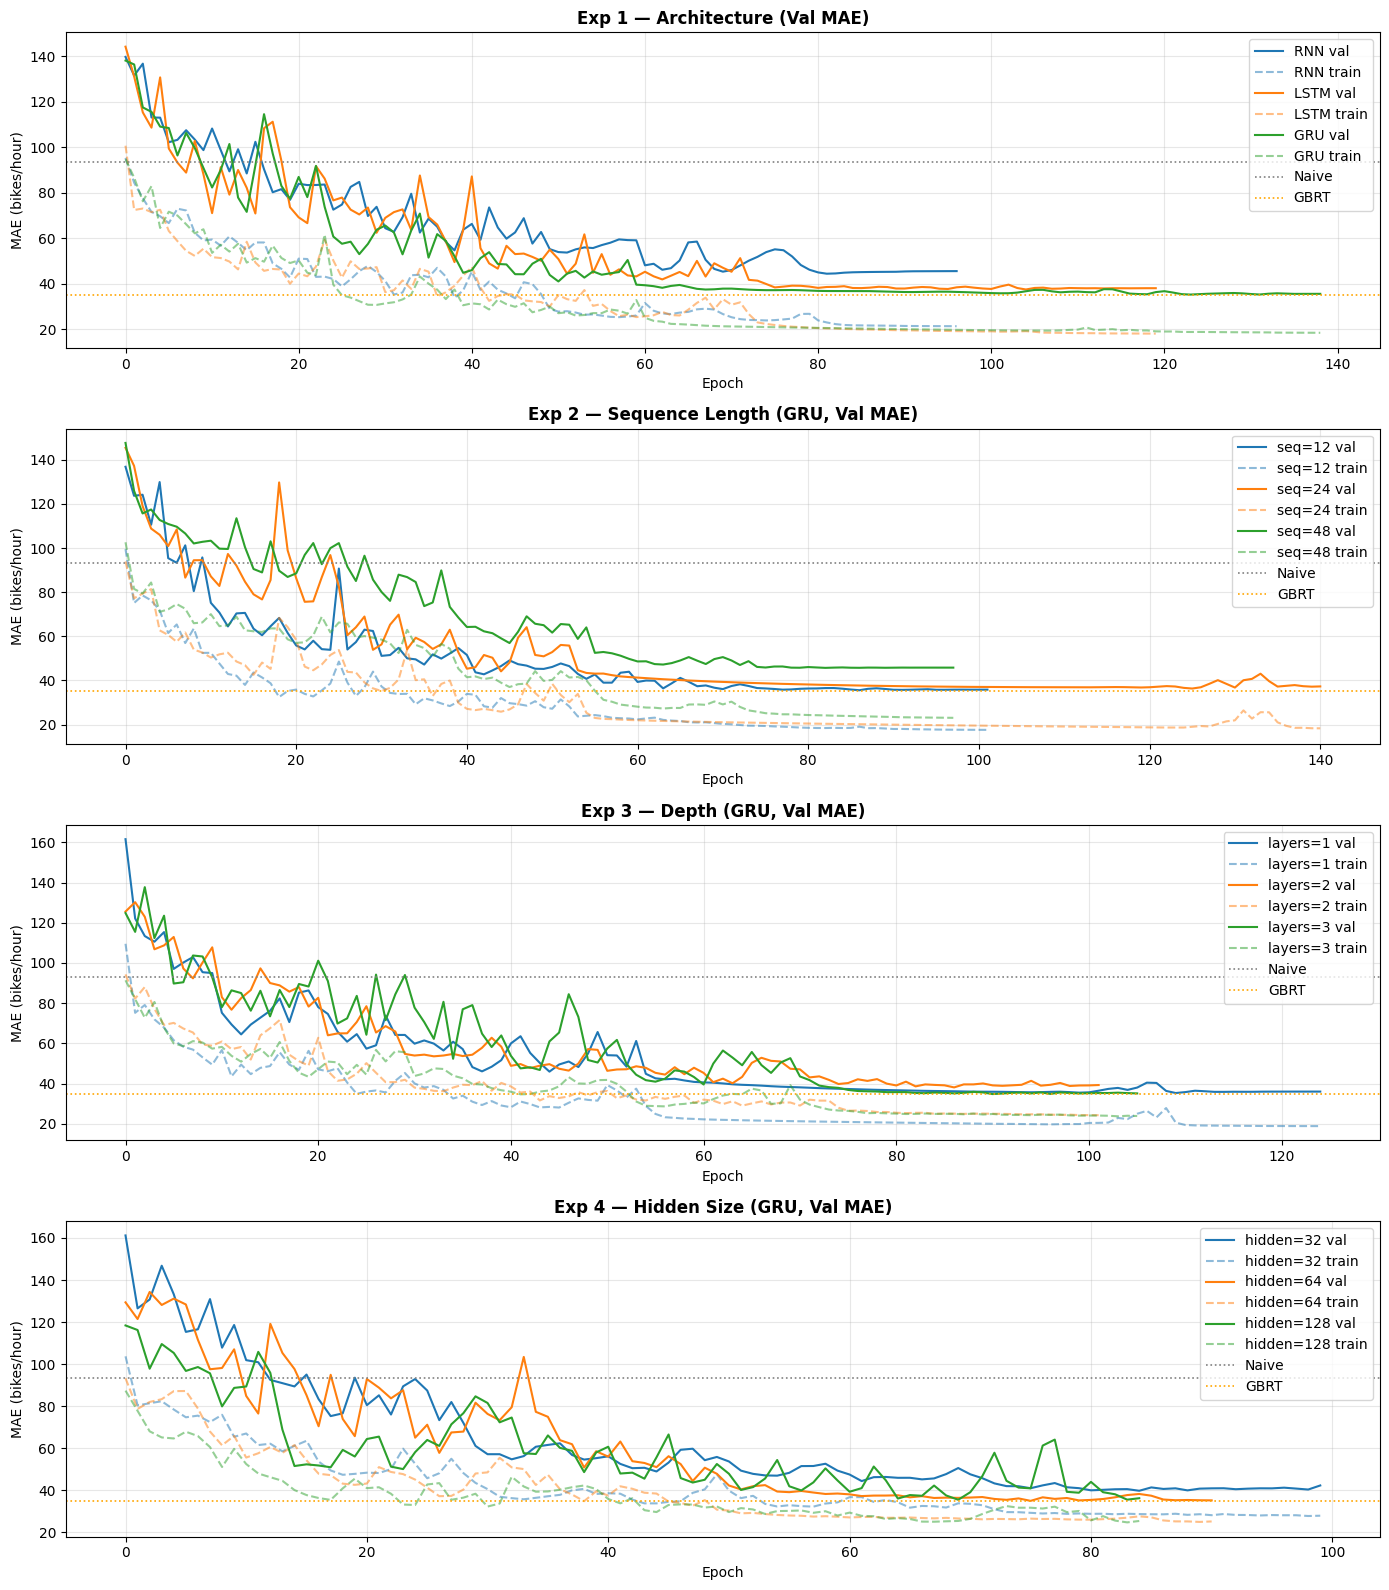

In [27]:
fig, axes = plt.subplots(4, 1, figsize = (14, 16))

# Exp 1: architecture comparison
ax = axes[0]
for arch, r in exp1_results.items():
    line = ax.plot([v * count_std for v in r['history']['val']], label = f"{arch.upper()} val")
    ax.plot([v * count_std for v in r['history']['train']], linestyle = '--',
            color = line[0].get_color(), alpha = 0.5, label = f"{arch.upper()} train")
ax.axhline(naive_mae[0], color = 'gray', linestyle = ':', linewidth = 1.2, label = 'Naive')
ax.axhline(gbrt_mae[0], color = 'orange', linestyle = ':', linewidth = 1.2, label = 'GBRT')
ax.set_title('Exp 1 — Architecture (Val MAE)', fontweight = 'bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE (bikes/hour)')
ax.legend()
ax.grid(True, alpha = 0.3)

# Exp 2: sequence length
ax = axes[1]
for seq_len, r in exp2_results.items():
    line = ax.plot([v * count_std for v in r['history']['val']], label = f"seq={seq_len} val")
    ax.plot([v * count_std for v in r['history']['train']], linestyle = '--',
            color = line[0].get_color(), alpha = 0.5, label = f"seq={seq_len} train")
ax.axhline(naive_mae[0], color = 'gray', linestyle = ':', linewidth = 1.2, label = 'Naive')
ax.axhline(gbrt_mae[0], color = 'orange', linestyle = ':', linewidth = 1.2, label = 'GBRT')
ax.set_title('Exp 2 — Sequence Length (GRU, Val MAE)', fontweight = 'bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE (bikes/hour)')
ax.legend()
ax.grid(True, alpha = 0.3)

# Exp 3: depth
ax = axes[2]
for nl, r in exp3_results.items():
    line = ax.plot([v * count_std for v in r['history']['val']], label = f"layers={nl} val")
    ax.plot([v * count_std for v in r['history']['train']], linestyle = '--',
            color = line[0].get_color(), alpha = 0.5, label = f"layers={nl} train")
ax.axhline(naive_mae[0], color = 'gray', linestyle = ':', linewidth = 1.2, label = 'Naive')
ax.axhline(gbrt_mae[0], color = 'orange', linestyle = ':', linewidth = 1.2, label = 'GBRT')
ax.set_title('Exp 3 — Depth (GRU, Val MAE)', fontweight = 'bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE (bikes/hour)')
ax.legend()
ax.grid(True, alpha = 0.3)

# Exp 4: hidden size
ax = axes[3]
for hs, r in exp4_results.items():
    line = ax.plot([v * count_std for v in r['history']['val']], label = f"hidden={hs} val")
    ax.plot([v * count_std for v in r['history']['train']], linestyle = '--',
            color = line[0].get_color(), alpha = 0.5, label = f"hidden={hs} train")
ax.axhline(naive_mae[0], color = 'gray', linestyle = ':', linewidth = 1.2, label = 'Naive')
ax.axhline(gbrt_mae[0], color = 'orange', linestyle = ':', linewidth = 1.2, label = 'GBRT')
ax.set_title('Exp 4 — Hidden Size (GRU, Val MAE)', fontweight = 'bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE (bikes/hour)')
ax.legend()
ax.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

In Experiment 1, the vanilla RNN curve is the highest and noisiest throughout training, reflecting the vanishing-gradient problem over 24-step sequences. GRU and LSTM converge to a much lower floor, with GRU doing so slightly faster and with less oscillation, which is consistent with its simpler gating structure. All three eventually beat the naive baseline by a wide margin, and GRU comes closest to the GBRT line.

In Experiment 2, `seq=12` converges the quickest and reaches the lowest validation MAE, suggesting the shorter window is easier for a single-layer GRU to learn from. Additionally, `seq=24` follows a similar curve but settles slightly higher. On the other hand, `seq=48` is visibly more erratic and plateaus well above the other two, with a notable train–val gap that points to gradient flow difficulty over the longer horizon.

In Experiment 3, the 1-layer and 3-layer models both converge smoothly, with the 3-layer model edging out the 1-layer by the end. The 2-layer curve is significantly more unstable, because the validation loss spikes before recovering, likely due to an unlucky random seed interacting with the tighter early-stopping window. Despite the instability of the 2-layer run, the 3-layer model benefits from additional dropout regularisation, keeping the train–val gap narrow.

In Experiment 4, all three hidden sizes converge at a similar rate, but `hidden=32` plateaus above the GBRT baseline, confirming it underfits. Finally, `hidden=64` and `hidden=128` reach comparable floors, with `hidden=64` marginally lower. The near-identical curves for 64 and 128 suggest the bottleneck at this point is not model capacity but rather that larger hidden states bring no further benefit.

In [28]:
print("=" * 52)
print("  FINAL COMPARISON  —  Val & Test MAE (bikes/hour)")
print("=" * 52)
print(f"{'Model':<32} {'Val MAE':>7} {'Test MAE':>9}")
print("-" * 52)
print(f"{'Naive baseline':<32} {naive_mae[0]:>7.2f} {naive_mae[1]:>9.2f}")
print(f"{'HistGradientBoosting':<32} {gbrt_mae[0]:>7.2f} {gbrt_mae[1]:>9.2f}")
print()
print(f"{'Best RNN (final model)':<32} {val_mae_final:>7.2f} {test_mae_final:>9.2f}")
print(f"  Config: GRU | seq_len={best_seq_len} | layers={best_num_layers} | hidden={best_hidden_size}")
print("=" * 52)

  FINAL COMPARISON  —  Val & Test MAE (bikes/hour)
Model                            Val MAE  Test MAE
----------------------------------------------------
Naive baseline                     93.26     80.78
HistGradientBoosting               35.02     33.94

Best RNN (final model)             35.79     35.58
  Config: GRU | seq_len=12 | layers=3 | hidden=64


## Conclusion

After the four experiments that were conducted to select the best RNN configuration, the results were:

| Experiment | Dimension | Winner | Val MAE |
|---|---|---|---|
| Exp 1 | Cell type | GRU | 35.21 bikes/hour |
| Exp 2 | Sequence length | seq_len=12 | 35.57 bikes/hour |
| Exp 3 | Depth | num_layers=3 | 34.77 bikes/hour |
| Exp 4 | Hidden size | hidden=64 | 35.01 bikes/hour |

Therefore, the best configuration, that was GRU, seq_len=12, num_layers=3, hidden=64, dropout=0.2, achieved:

| Model | Val MAE | Test MAE |
|---|---|---|
| Naive baseline | 93.26 | 80.78 |
| HistGradientBoosting | 35.02 | 33.94 |
| **Best RNN** | **35.79** | **35.58** |

This RNN comes within 0.77 bikes/hour of the GBRT baseline on validation and within 1.64 bikes/hour on test, corresponding to a 62% reduction in MAE over the naive baseline (from 93.26 to 35.79). This is a strong result given that the GBRT model has access to explicit hand-crafted lag features (1h, 1d, 7d), while the RNN learns temporal dependencies entirely from raw sequences. The small remaining gap likely reflects that explicit lag features give the tree model access to periodicity signals that the RNN must infer implicitly from the sequence structure.